In [1]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from utils import *
from genData import *
from plot import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(1)
torch.manual_seed(1)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. No GPU found.")

def compute_detection_statistic(images, method= 'mean'):
    images_np = np.abs(images)
                          
    return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Configuration
det = 'H1L1'
f0 = 20
size = (512, 64)
Tsft = 14400
train_level = 32
batch_size = 8

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

25-08-09 20:33:33.121 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


GPU Name: Tesla V100-PCIE-16GB


<All keys matched successfully>

In [2]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print the number of trainable parameters
print(f"Number of trainable parameters: {count_trainable_parameters(model)}")

Number of trainable parameters: 34879348


In [3]:

# Initialize lists for depth and pdet
depth = []
pdet = []
max_train_levels = [5*i for i in range(1, 21)]  
# Compute pdet
noise_data = np.empty((1000,) + size + (4,))
for i in range(noise_data.shape[0]):
    noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise_data = normalize(noise_data)
noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)

noise_predictions = []
with torch.no_grad():
    for batch in tqdm(noise_loader, desc="Processing noise"):
        images = batch[0].to(device)
        outputs = model(images)
        noise_predictions.append(outputs.cpu().numpy())
noise_predictions = np.concatenate(noise_predictions, axis=0)
noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')

    
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth.append(Sn)
    pdet.append(pdet_value)

# Convert to numpy arrays
depth = np.array(depth)
pdet = np.array(pdet)

Processing Sn=100: 100%|██████████| 125/125 [00:06<00:00, 20.65it/s]


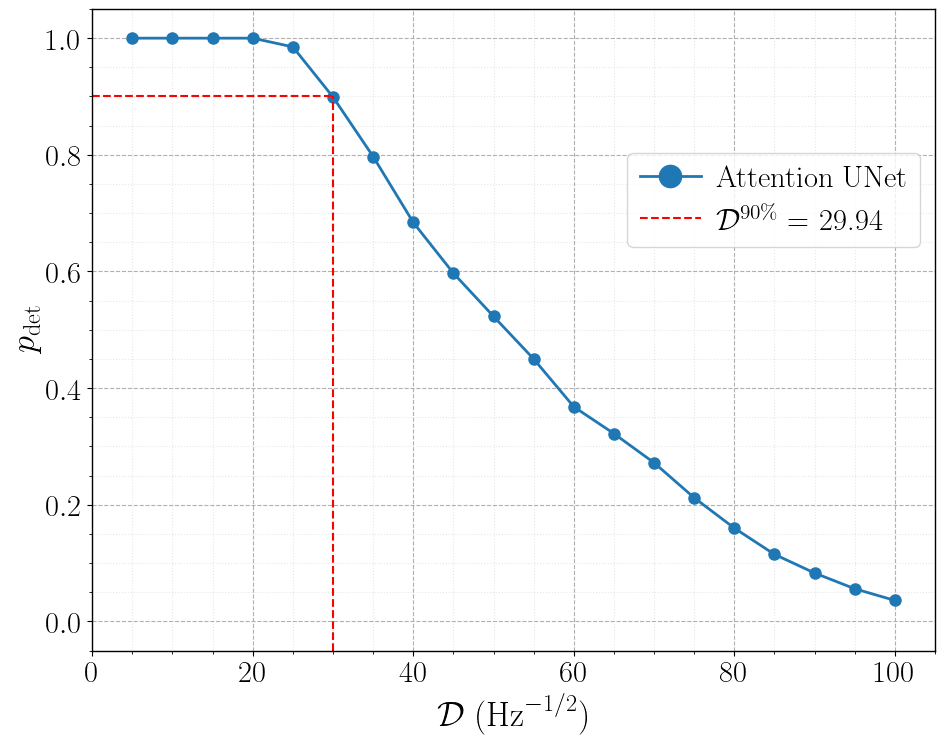

In [4]:
# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

            
# Create figure and axis
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Use tab10 colormap for distinct colors

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Weave data as a line
#ax.plot(depth_mf[:-2], pdet_mf[:-2], color='k', label='Weave', lw=2)
sort_idx = np.argsort(depth)
depth_sorted = depth[sort_idx]
pdet_sorted = pdet[sort_idx]
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])  # Reverse to handle decreasing pdet

# Plot Attention UNet data with line and markers
ax.plot(depth, pdet, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
ax.set_ylabel(r'$p_{\mathrm{det}}$')
ax.legend(fontsize=22, loc='upper right', markerscale=2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1, 0.8))
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
#plt.savefig(f'../result/plots/pdet_with_error_bars.pdf', dpi=300, bbox_inches='tight')

In [12]:
max_train_levels = [40.2790, 29.5]

depth_ex = []
pdet_ex = []
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth_ex.append(Sn)
    pdet_ex.append(pdet_value)

# Convert to numpy arrays
depth_ex = np.array(depth_ex)
pdet_ex = np.array(pdet_ex)

Processing Sn=29.5: 100%|██████████| 125/125 [00:06<00:00, 19.22it/s]


In [13]:
depth_ex, pdet_ex

(array([40.279, 29.5  ]), array([0.692, 0.918]))

In [14]:
binomialError(pdet_ex, 1000)*100

array([1.45991781, 0.86761743])

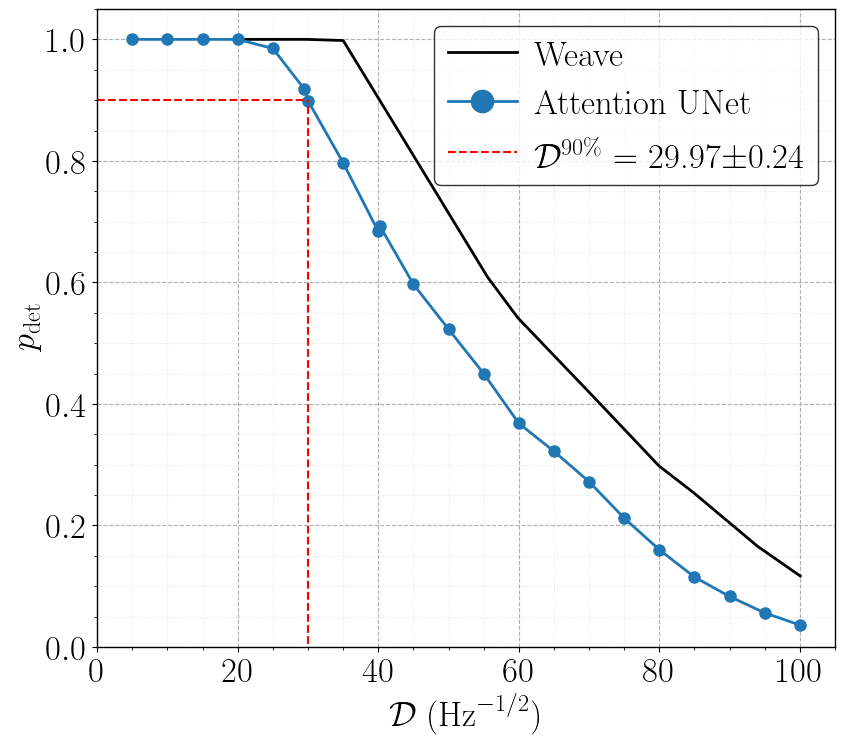

In [ ]:
# Insert depth_ex and pdet_ex into depth and pdet to maintain ascending order
# Combine all points
combined = np.vstack((np.column_stack((depth, pdet)), np.column_stack((depth_ex, pdet_ex))))
# Sort by depth (first column)
sorted_indices = np.argsort(combined[:, 0])
depth_combined = combined[sorted_indices, 0]
pdet_combined = combined[sorted_indices, 1]

# Use only the first len(depth)-4 points from combined data (to match depth[:-4])
n_points = len(depth_combined)
depth_plot = depth_combined[:n_points]
pdet_plot = pdet_combined[:n_points]

# Interpolate depth at pdet = 0.9
# Sort by depth for interpolation (already sorted, but confirm)
sort_idx = np.argsort(depth_plot)
depth_sorted = depth_plot[sort_idx]
pdet_sorted = pdet_plot[sort_idx]



# Create figure and axis
fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

            
pdet_mf *= (921600/864000)**0.5
pdet_mf[pdet_mf>1] = 1
ax.plot(depth_mf[:-1], pdet_mf[:-1], color='k', label='Weave', lw=2)



dpdet = binomialError(pdet_sorted, 1000)
# Compute interpolation and error
d90, d90_err = interpolation_error(0.9, depth_sorted, pdet_sorted, dpdet)

# Plot combined Attention UNet data with line and markers
ax.plot(depth_plot, pdet_plot, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}'r'$\pm$'+ f'{d90_err:.2f}')



# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$', fontsize=25)
ax.set_ylabel(r'$p_{\mathrm{det}}$', fontsize=25)
ax.legend(fontsize=25, loc=1, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', which='major', labelsize=25)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
plt.savefig('../result/plots/pdet_20Hz.pdf', dpi=300, bbox_inches='tight')

In [10]:
d90, d90_err

(29.973684210526315, 0.23788850063653572)

In [17]:
np.savez(f'../result/pdet_depth_{f0}Hz.npz', pdet=pdet_combined, depth=depth_combined)

# Duty factor

In [ ]:
model.eval()


duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]  # Range of duty factors (1.0 = no gaps, 0.4 = 60% gaps)

# Initialize results storage
results = {df: {'depth': [], 'pdet': []} for df in duty_factors}

# Process each duty factor
for duty_factor in duty_factors:
    if duty_factor == 0.7:
        max_train_levels = [d for d in range(23, 27)]  
    elif duty_factor == 0.6:
        max_train_levels = [d for d in range(20, 24)]  
    elif duty_factor >= 0.8:
        max_train_levels = [d for d in range(27, 33)]  
        
    print(f"\nProcessing duty factor: {duty_factor}")
    num_zero_cols = int(size[1] * (1 - duty_factor))
    zero_cols = np.random.choice(size[1], size=num_zero_cols, replace=False)  # Randomly select columns
    
    # Compute noise statistics (no duty factor applied)
    noise_data = np.empty((1000,) + size + (4,))
    for i in range(noise_data.shape[0]):
        noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)

    noise_data = apply_duty_factor(noise_data, duty_factor, size, zero_cols)  # Apply duty factor
    noise_data = normalize(noise_data)
    noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)
        
    noise_predictions = []
    with torch.no_grad():
        for batch in tqdm(noise_loader, desc="Processing noise"):
            images = batch[0].to(device)
            outputs = model(images)
            noise_predictions.append(outputs.cpu().numpy())
    noise_predictions = np.concatenate(noise_predictions, axis=0)
    noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')
    
    # Process each noise level
    for Sn in max_train_levels:
        # Generate noise and add to targets
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        
        # Apply duty factor to data
        data = apply_duty_factor(data, duty_factor, size, zero_cols)
        
        data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

        # Compute predictions
        predictions = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}, Duty={duty_factor}"):
                images = images.to(device)
                outputs = model(images)
                predictions.append(outputs.cpu().numpy())
        predictions = np.concatenate(predictions, axis=0)

        # Compute detection statistic
        stats = compute_detection_statistic(predictions, method='mean_sq')

        # Compute pdet
        x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
        mask = stats > x_pfa
        pdet_value = mask.sum() / mask.size

        # Store results
        results[duty_factor]['depth'].append(Sn)
        results[duty_factor]['pdet'].append(pdet_value)

In [18]:
duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]
results_file = '../result/D90_duty_factor_results.npz'
save_dict = {}

for df in duty_factors:
    pdet = np.array(results[df]['pdet'])
    depth = np.array(results[df]['depth']) 

    save_dict[f'depth_df{df}'] = depth
    save_dict[f'pdet_df{df}'] = pdet   
    

np.savez(results_file, **save_dict)

In [3]:
data = np.load(f'../result/D90_duty_factor_results.npz', allow_pickle=True)

[0.973 0.951 0.941 0.921 0.901 0.88 ]
[27 28 29 30 31 32]
[0.947 0.92  0.906 0.87  0.854 0.833]
[27 28 29 30 31 32]
[0.932 0.911 0.876 0.862 0.847 0.808]
[27 28 29 30 31 32]
[0.94  0.927 0.895 0.88 ]
[23 24 25 26]
[0.976 0.962 0.935 0.899]
[20 21 22 23]


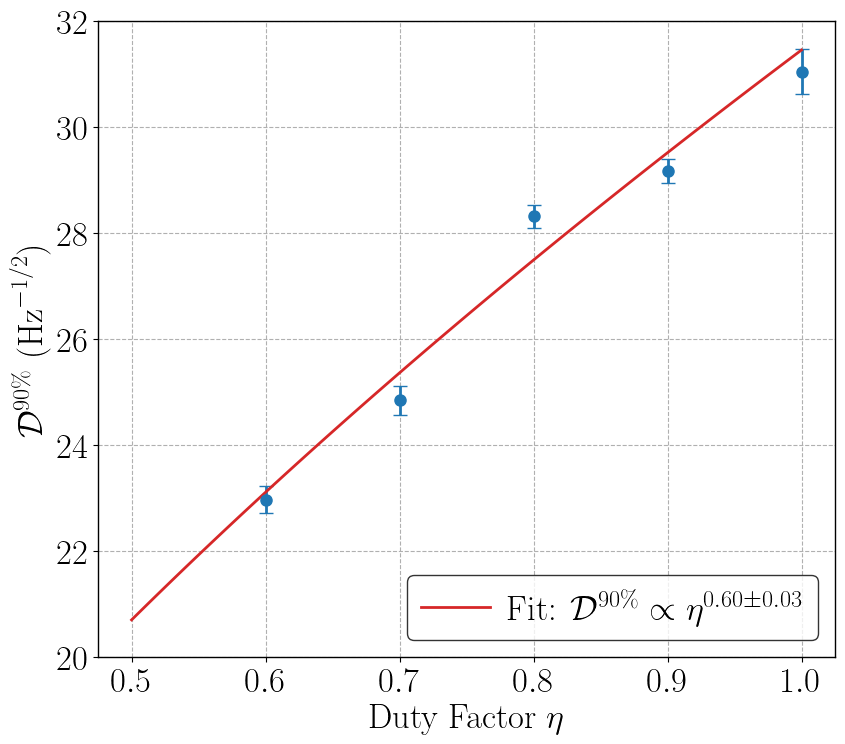

In [5]:
D90 = []
D90_err = []

duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]


for duty_factor in duty_factors:
    pdet = data[f'pdet_df{duty_factor}']
    depth = data[f'depth_df{duty_factor}']
    
    print(pdet)
    print(depth)
    
    pdet = np.array(pdet)
    depth = np.array(depth)
    dpdet = binomialError(pdet, 1000)

    # Compute interpolation and error
    x, x_error = interpolation_error(0.9, depth, pdet, dpdet)
    D90.append(x)
    D90_err.append(x_error)
    
    
#D90[0] = 31.04
D90 = np.array(D90)[::-1]
D90_err = np.array(D90_err)[::-1]


duty_factors = np.array(duty_factors)[::-1]

# Define the power law function
from scipy.optimize import curve_fit
def power_law(x, k, a):
    return k * (x ** a)

# Normalize tobs


# Fit the power law with errors
popt, pcov = curve_fit(power_law, duty_factors, D90, p0=[1.3, 0.1], sigma=D90_err, absolute_sigma=True)
k, a = popt
k_err, a_err = np.sqrt(np.diag(pcov))

# Plot
fig, ax = plt.subplots(figsize=(9, 8))


ax.errorbar(duty_factors, D90, yerr=D90_err, fmt='o', color='tab:blue', 
            linewidth=2, markersize=8, capsize=5)

# Generate fitted curve
duty_factor_fit = np.linspace(0.5, 1, 100)
depth_fit = power_law(duty_factor_fit, k, a)
ax.plot(duty_factor_fit, depth_fit, linestyle='-', color='tab:red', 
        linewidth=2, label=f'Fit: $\\mathcal{{D}}^{{90\\%}} \\propto \eta^{{{a:.2f} \\pm {a_err:.2f}}}$')
# Axis labels and styling
ax.set_xlabel(r'$\mathrm{Duty\;Factor} \; \eta$')
ax.set_ylabel(r'$\mathcal{D}^{90\%}\; (\mathrm{Hz}^{-1/2})$')
#ax.set_xticks([5, 10, 15, 20])  # Ticks at 5, 10, 15, 20 days

ax.legend(loc=4, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_ylim(20, 32)

# Save figure
plt.tight_layout()
fig.savefig('../result/plots/D90_duty_factor.pdf', dpi=300, bbox_inches='tight')

In [6]:
D90, D90_err

(array([22.97222222, 24.84375   , 28.31428571, 29.16666667, 31.04761905]),
 array([0.25929807, 0.26712787, 0.21331914, 0.22995795, 0.42899768]))

# Generalization to $T_\mathrm{obs}$

In [2]:
tobs = [32, 64, 96, 128]
train_level_level = [32, 32, 32, 40]
time_list = [5, 10, 16, 21]

# Compute depth at 90% detection for each Tobs
results = {}
depth_values = []
for t, train_level, time in zip(tobs, train_level_level, time_list):

    if t == 32:
        Sn_values = np.linspace(23, 27, 5)  # Range of Sn values
    if t== 64:
        Sn_values = np.linspace(29, 33, 5)  # Range of Sn values
    if t== 96:
        Sn_values = np.linspace(33, 37, 5)  # Range of Sn values
    if t== 128:
        Sn_values = np.linspace(34, 38, 5)  # Range of Sn values

    size = (512, t)
    # Initialize model and load weights
    model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
    version = f'H1L1_a1b1_20Hz_D{train_level}-{train_level}_T{time}_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x{t}_MSELoss_dropout0'
    try:
        model.load_state_dict(torch.load(f"../trained_model/20Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False))
    except FileNotFoundError:
        print(f"Warning: Model file for Tobs={t} not found. Setting depth to NaN.")
        depth_values.append(np.nan)
        continue
    model.eval()

    # Load validation data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{t}_{Tsft}s_4c_traindata_n1000_seed4.npz'
    try:
        targets = np.load(filename, allow_pickle=True)['clean_image']
    except FileNotFoundError:
        print(f"Warning: Validation data for Tobs={t} not found. Setting depth to NaN.")
        depth_values.append(np.nan)
        continue

    # Compute x_pfa from pure noise once
    noise = np.empty((1000,) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
    noise = normalize(noise)
    noise_loader = load_dataset(noise, batch_size=8, shuffle=False)
    noise_stats = []
    with torch.no_grad():
        for images, in tqdm(noise_loader, desc=f"Computing x_pfa for Tobs={t}"):
            images = images.to(device)
            outputs = model(images)
            stats = compute_detection_statistic(outputs.cpu().numpy(), method='mean_sq')
            noise_stats.append(stats)
    noise_stats = np.concatenate(noise_stats)
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)

    # Compute pdet for each Sn
    pdet_per_sn = []
    for Sn in Sn_values:
        # Generate signal data
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        data_loader = load_dataset(data, batch_size=8, shuffle=False)

        # Compute detection statistics
        stats = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f'Evaluating Tobs={t}, Sn={Sn:.2f}'):
                images = images.to(device)
                outputs = model(images)
                batch_stats = compute_detection_statistic(outputs.cpu().numpy(), method='mean_sq')
                stats.append(batch_stats)
        stats = np.concatenate(stats)

        # Compute pdet
        mask = stats > x_pfa
        pdet = mask.sum() / stats.size
        pdet_per_sn.append(pdet)
    
    
    result_dict = {'pdet_per_sn': pdet_per_sn, 'Sn_values': Sn_values.tolist()}
    try:
        # Sort by pdet to ensure monotonicity for interpolation
        sort_idx = np.argsort(pdet_per_sn)[::-1]  # Descending order
        pdet_sorted = np.array(pdet_per_sn)[sort_idx]
        sn_sorted = Sn_values[sort_idx]
        # Check if pdet=0.9 is within the range of pdet_sorted
        if pdet_sorted.min() > 0.9 or pdet_sorted.max() < 0.9:
            raise ValueError("pdet=0.9 is outside the range of pdet values")
        result_dict['pdet_sorted'] = pdet_sorted.tolist()
        result_dict['sn_sorted'] = sn_sorted.tolist()
    except ValueError as e:
        print(f"Warning: Interpolation failed for Tobs={t} ({e}). Setting depth to NaN.")
        depth_values.append(np.nan)
        result_dict['pdet_sorted'] = []
        result_dict['sn_sorted'] = []
    results[f'Tobs_{t}'] = result_dict
# Save all numbers to a .npz file
np.savez('./depth_interpolation_results.npz', **results)

Evaluating Tobs=128, Sn=38.00: 100%|██████████| 125/125 [00:10<00:00, 12.42it/s]


[0.94  0.902 0.879 0.845 0.82 ] [23. 24. 25. 26. 27.]
[0.935 0.925 0.883 0.877 0.865] [29. 30. 31. 32. 33.]
[0.909 0.882 0.865 0.856 0.838] [33. 34. 35. 36. 37.]
[0.929 0.919 0.897 0.867 0.853] [34. 35. 36. 37. 38.]


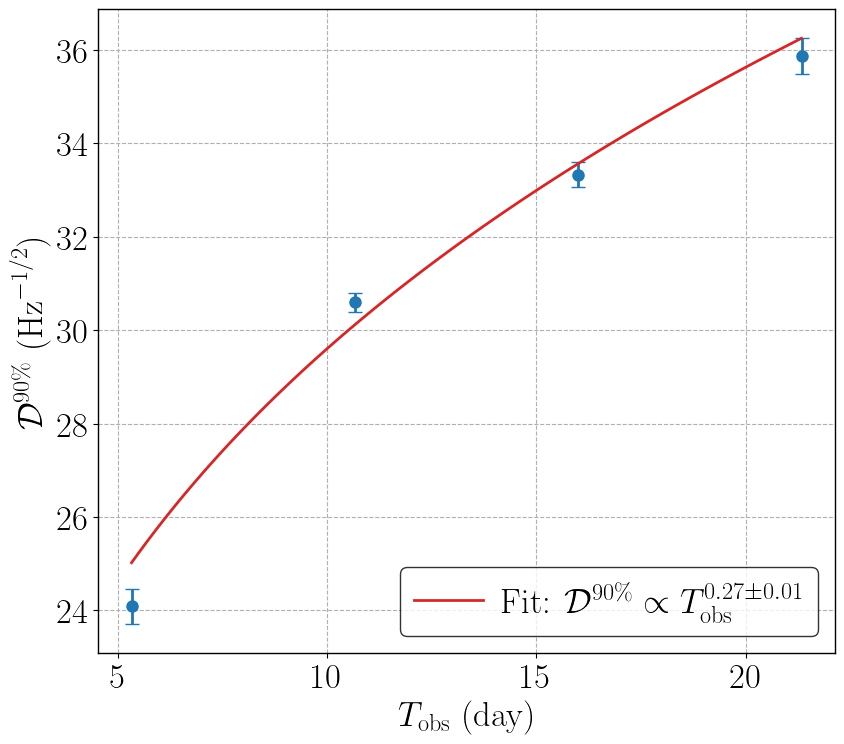

In [8]:
data = np.load('./depth_interpolation_results.npz', allow_pickle=True)
tobs = [32, 64, 96, 128]
D90 = []
D90_err = []
for t in tobs:
    pdet = data[f'Tobs_{t}'].item()['pdet_per_sn']
    depth = data[f'Tobs_{t}'].item()['Sn_values']

    pdet = np.array(pdet)
    depth = np.array(depth)
    dpdet = binomialError(pdet, 1000)
    print(pdet, depth)
    # Compute interpolation and error
    x, x_error = interpolation_error(0.9, depth, pdet, dpdet)
    D90.append(x)
    D90_err.append(x_error)
    
D90 = np.array(D90)
D90_err = np.array(D90_err)

# Define the power law function
from scipy.optimize import curve_fit
def power_law(tobs_normalized, k, a):
    return k * (tobs_normalized ** a)

# Normalize tobs
tobs = np.array(tobs) 

# Fit the power law with errors
popt, pcov = curve_fit(power_law, tobs/6, D90, p0=[1.3, 0.1], sigma=D90_err, absolute_sigma=True)
k, a = popt
k_err, a_err = np.sqrt(np.diag(pcov))

# Plot
fig, ax = plt.subplots(figsize=(9, 8))


ax.errorbar(tobs/6, D90, yerr=D90_err, fmt='o', color='tab:blue', 
            linewidth=2, markersize=8, capsize=5)

# Generate fitted curve
tobs_fit = np.linspace(32, 128, 100)
depth_fit = power_law(tobs_fit/6, k, a)
ax.plot(tobs_fit/6, depth_fit, linestyle='-', color='tab:red', 
        linewidth=2, label=f'Fit: $\\mathcal{{D}}^{{90\\%}} \\propto T_\\mathrm{{obs}}^{{{a:.2f} \\pm {a_err:.2f}}}$')
# Axis labels and styling
ax.set_xlabel(r'$T_{\mathrm{obs}}$ (day)')
ax.set_ylabel(r'$\mathcal{D}^{90\%}\; (\mathrm{Hz}^{-1/2})$')
#ax.set_xticks([5, 10, 15, 20])  # Ticks at 5, 10, 15, 20 days

ax.legend(loc=4, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
#ax.set_ylim(20, 40)

# Save figure
plt.tight_layout()
plt.savefig('../result/plots/depth_vs_tobs.pdf', dpi=300, bbox_inches='tight')

In [10]:
D90, D90_err

(array([24.08695652, 30.5952381 , 33.33333333, 35.86363636]),
 array([0.37999611, 0.19665544, 0.26160447, 0.38380346]))